# Self-Consistency Check — Pure Quadrupoles (ALBA-I, no sextupoles)

Replaces AT tracking with a finite difference of the **analytical ORM** (`Rab_thick2_`).
If `dRij_dqk_thick23` is the exact derivative of `Rab_thick2_`, the error is 0%.
A non-zero result exposes an inconsistency between the two analytical formulas.

Tensor convention: axis 0 = quadrupole, axis 1 = BPM, axis 2 = corrector.

In [8]:
from pathlib import Path
import sys
import numpy as np
import at
sys.path.insert(0, str(Path("../scripts")))

from ACalORAT import AnaORM, numerical, read, math_utils, plot_utils

## Lattice preparation

Same settings as `Quadrupoles_ALBAI_no_sext.ipynb`: linearize=1 (remove sextupoles), fringes on.

In [9]:
ROOT = Path("../")
ring, ind = read.ALBA(ROOT / "data" / "THERING.mat")

# Remove sextupoles (and higher): zero PolynomB from index 2 upward
for el in filter(at.checkattr("PolynomB"), ring):
    for i in range(2, len(el.PolynomB)):
        el.PolynomB[i] = 0.0

# Zero corrector kicks so the closed orbit is nominal
for i in ind["cor"]["h"]: ring[i].KickAngle = np.array([0.0, 0.0])
for i in ind["cor"]["v"]: ring[i].KickAngle = np.array([0.0, 0.0])

## Semi-numerical Jacobian

`dORM_dq_semi` differentiates the **analytical ORM** (`Rab_thick2_`) via finite differences.
A small step is fine since the analytical ORM has no numerical noise.

In [10]:
step = 1e-6
semi_v = numerical.dORM_dq_semi(ring, ind, step, "v")
semi_h = numerical.dORM_dq_semi(ring, ind, step, "h")

hii


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 109 out of 112 | elapsed:    5.5s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done 112 out of 112 | elapsed:    5.6s finished


hii


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done 109 out of 112 | elapsed:    4.8s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 112 out of 112 | elapsed:    4.9s finished


## Analytical Jacobian

In [11]:
cORM_v = AnaORM.AnaORM(ring, "v", ind)
cORM_v.assign_optics()
ana_v = cORM_v.dRij_dqk_thick23(cORM_v.bpm, cORM_v.cor, cORM_v.quad)

cORM_h = AnaORM.AnaORM(ring, "h", ind)
cORM_h.assign_optics()
cORM_h.dip.correct_entrance()
ana_h  = cORM_h.dRij_dqk_thick23(cORM_h.bpm, cORM_h.cor, cORM_h.quad)
ana_h += cORM_h.dRij_dqk_thick23_disp(cORM_h.bpm, cORM_h.cor, cORM_h.quad)

## Results

Vertical   nRMSE per quad (mitjana): 0.0589%
Horizontal nRMSE per quad (mitjana): 0.1164%


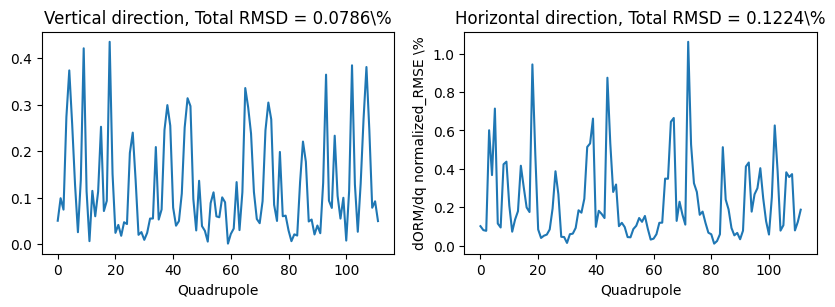

In [13]:
err_v = math_utils.normalized_RMSE(semi_v, ana_v, dims=(1, 2))
err_h = math_utils.normalized_RMSE(semi_h, ana_h, dims=(1, 2))
print(f"Vertical   nRMSE per quad (mitjana): {err_v.mean():.4f}%")
print(f"Horizontal nRMSE per quad (mitjana): {err_h.mean():.4f}%")

plot_utils.plot_both_Zeus(semi_v, semi_h, ana_v, ana_h, xlabel="Quadrupole")

## Tensor Inspection

Residual patterns to diagnose *where* the error lives: per-corrector, per-BPM, or per-quadrupole slices.
A corrector-concentrated pattern → Ikc1_/Iks1_ derivative missing; quad-concentrated → quad integral issue.

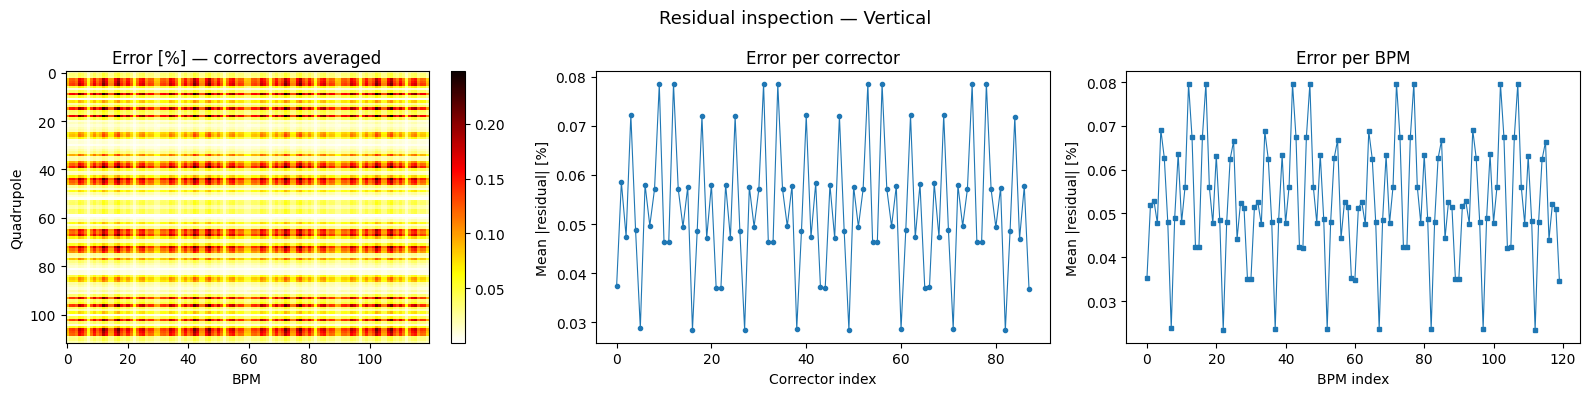


--- Vertical ---
Top-5 correctors by error:
78    0.078581
12    0.078578
53    0.078578
56    0.078545
31    0.078534

Top-5 BPMs by error:
72     0.079633
17     0.079625
77     0.079625
107    0.079605
12     0.079593


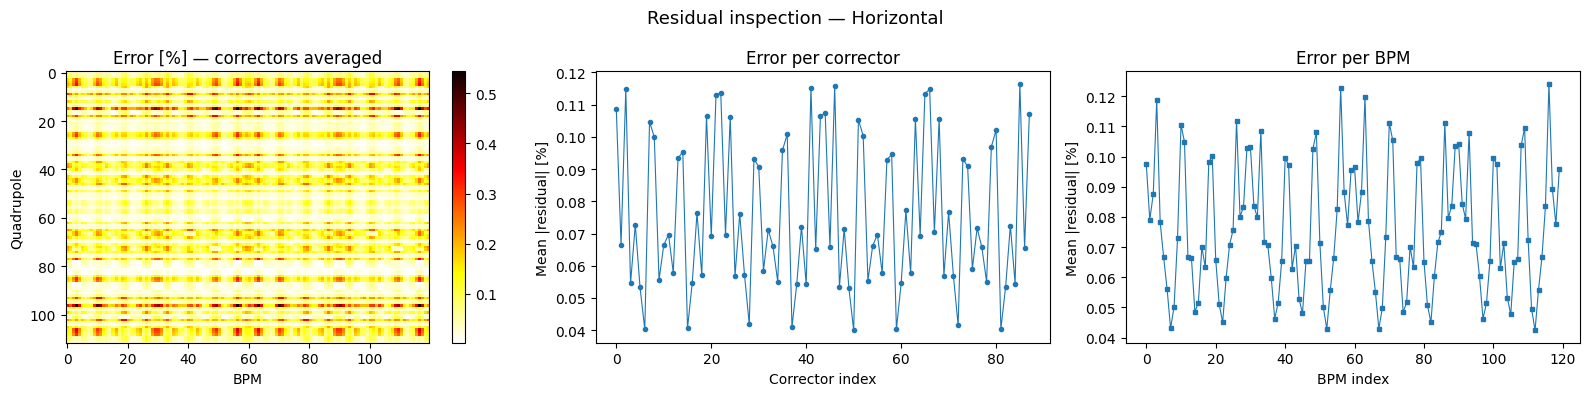


--- Horizontal ---
Top-5 correctors by error:
85    0.116498
46    0.115676
41    0.115202
2     0.114824
66    0.114722

Top-5 BPMs by error:
116    0.124142
56     0.122703
63     0.119676
3      0.118773
26     0.111897


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

def inspect_residual(num, ana, label):
    """
    Show where the residual (num - ana) is concentrated.
    
    Plots:
      - 2D heatmap: quads × BPMs (correctors averaged out)
      - Per-corrector nRMSE (averaged over quads and BPMs)
      - Per-BPM nRMSE (averaged over quads and correctors)
    """
    residual = num - ana
    scale = np.sqrt(np.mean(num**2))  # global RMS of reference
    rel = np.abs(residual) / (scale + 1e-30) * 100  # % relative

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"Residual inspection — {label}", fontsize=13)

    # 1. Heatmap: quads (axis 0) × BPMs (axis 1), correctors averaged
    im = axes[0].imshow(rel.mean(axis=2), aspect="auto", origin="upper",
                        cmap="hot_r", interpolation="nearest")
    axes[0].set_xlabel("BPM")
    axes[0].set_ylabel("Quadrupole")
    axes[0].set_title("Error [%] — correctors averaged")
    plt.colorbar(im, ax=axes[0])

    # 2. Per-corrector: RMSE averaged over quads and BPMs
    per_cor = rel.mean(axis=(0, 1))
    axes[1].plot(per_cor, "o-", ms=3, lw=0.8)
    axes[1].set_xlabel("Corrector index")
    axes[1].set_ylabel("Mean |residual| [%]")
    axes[1].set_title("Error per corrector")

    # 3. Per-BPM: RMSE averaged over quads and correctors
    per_bpm = rel.mean(axis=(0, 2))
    axes[2].plot(per_bpm, "s-", ms=3, lw=0.8)
    axes[2].set_xlabel("BPM index")
    axes[2].set_ylabel("Mean |residual| [%]")
    axes[2].set_title("Error per BPM")

    plt.tight_layout()
    plt.show()

    # Summary table: top-5 correctors and top-5 BPMs by error
    top_cor = pd.Series(per_cor).nlargest(5)
    top_bpm = pd.Series(per_bpm).nlargest(5)
    print(f"\n--- {label} ---")
    print("Top-5 correctors by error:")
    print(top_cor.to_string())
    print("\nTop-5 BPMs by error:")
    print(top_bpm.to_string())

inspect_residual(semi_v, ana_v, "Vertical")
inspect_residual(semi_h, ana_h, "Horizontal")